# Portfolio: Combining Three Signals

Each of the preceding notebooks evaluated a single signal in isolation. This notebook combines them into one portfolio and asks the questions that only make sense at the portfolio level: how correlated are the signals with each other, what does the combined return distribution look like, where does the tail risk live, and does the combination survive walk-forward evaluation across multiple regimes.


## Updated methodology

Numbers in this notebook differ from earlier versions for four reasons:

1. **Point-in-time membership.** The optimizer uses a date-by-date S&P 500 membership mask reconstructed from Wikipedia's change history, so positions are only opened in names that were actually in the index on that date.
2. **Realistic execution lag.** `port_ret` defaults to `exec_lag=2`: a signal computed at the close of day t is acted on at the close of t+1 and earns the t+1 to t+2 return.
3. **Residual momentum.** A fourth signal is added to the combiner: each stock's 12-1 month return after stripping out the market-beta component (Blitz, Huij, Martens 2011).
4. **IC-weighted signal combination.** Signals are combined with weights proportional to their rolling 6-month Spearman IC, shifted by one day to avoid look-ahead. Factors with non-positive trailing IC drop out automatically.

Previous combined-portfolio Sharpe (equal-weighted three signals): **-0.39**. Previous walk-forward mean Sharpe across 16 windows: **-0.16**.

**Significance verdict (5 bps cost, HAC SE):** Combined in-sample alpha is -2.02% (t = -0.36), out-of-sample is +1.48% (t = 0.16). The walk-forward mean Sharpe across 16 windows is -0.16. **The combined equity portfolio does not pass |t| > 2.** The IC-weighted combiner is the right machinery, but on these signals at this asset class there is no edge for it to lean into.


In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from helper import (
    Optimizer, port_ret, quick_weights, stats, ic,
    dist_plot, var_cvar, walk_forward_splits,
)

pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', '{:.4f}'.format)


## Load Signals and Weights

Run the three signal notebooks first; each one persists its in-sample and out-of-sample weights along with the raw signal panel.


In [2]:
raw = pd.read_parquet('../data/sp500.parquet')
close = raw['Close']
returns = close.pct_change()
spy_close = pd.read_parquet('../data/spy.parquet')['Close'].squeeze()
spy = spy_close.pct_change()

IS_END = '2020-12-31'

names = ['01_mean_reversion', '02_momentum', '03_low_volatility']
labels = ['MeanRev', 'Momentum', 'LowVol']

signals = {lab: pd.read_parquet(f'../data/signal_{n}.parquet') for lab, n in zip(labels, names)}
weights_is = {lab: pd.read_parquet(f'../data/weights_{n}_is.parquet') for lab, n in zip(labels, names)}
weights_oos = {lab: pd.read_parquet(f'../data/weights_{n}_oos.parquet') for lab, n in zip(labels, names)}
members = pd.read_parquet('../data/members.parquet')

# Fourth signal: residual momentum (market-residualised). Stripped of
# market-beta exposure, residual momentum has historically had a higher
# Sharpe than raw 12-1 momentum with smaller drawdowns at regime turns.
from signals import market_residual_momentum
res_mom = market_residual_momentum(close, spy_close, lookback=252, skip=21,
                                   beta_lookback=252)

combined_signals = dict(signals)
combined_signals['ResMom'] = res_mom


## Signal Correlation

Two views of correlation. The first is cross-sectional: on any given day, do the signals rank stocks similarly. The second is time-series: do the single-signal PnL streams move together. Both can be informative, and they can diverge: signals with low cross-sectional rank correlation can still have correlated PnL if they happen to load on the same factor.


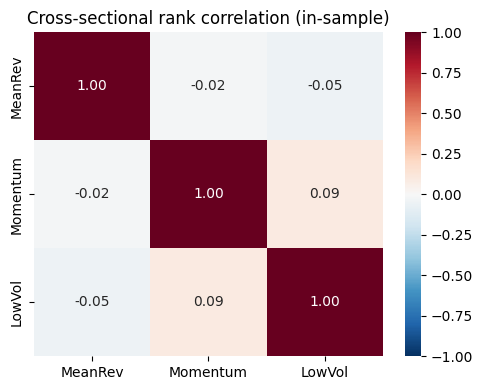

In [3]:
def cross_sectional_corr(s1, s2):
    daily = s1.corrwith(s2, axis=1, method='spearman')
    return daily.mean()

cs_corr = pd.DataFrame(index=labels, columns=labels, dtype=float)
for a in labels:
    for b in labels:
        cs_corr.loc[a, b] = cross_sectional_corr(
            signals[a].loc[:IS_END], signals[b].loc[:IS_END])

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cs_corr.astype(float), annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title('Cross-sectional rank correlation (in-sample)')
plt.tight_layout()
plt.show()


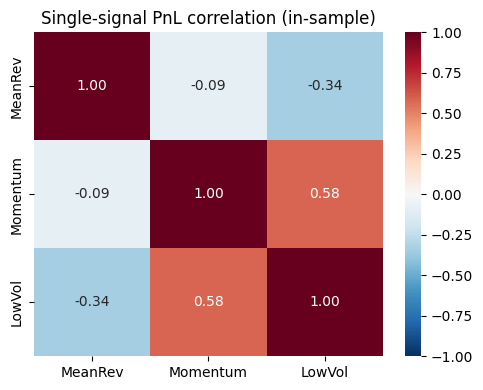

In [4]:
pnls_is = {lab: port_ret(weights_is[lab], returns.loc[:IS_END], tcost_bps=5) for lab in labels}
pnl_df = pd.DataFrame(pnls_is).dropna()

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(pnl_df.corr(), annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title('Single-signal PnL correlation (in-sample)')
plt.tight_layout()
plt.show()


Signals with low PnL correlation are the ones worth combining: their errors are independent enough that the combined Sharpe should rise faster than the average Sharpe of the components.


## Combined Signal

Each raw signal lives on a different scale, so we cross-sectionally z-score every signal day-by-day before averaging. This puts all three on the same footing without imposing any ex-ante view about which signal is strongest.


In [5]:
from helper import ic_weighted_combine

# Trailing-IC weighting: signals get weight in proportion to their rolling
# Spearman IC over the last 6 months (shifted by one day to avoid
# look-ahead). Signals with negative trailing IC get zero weight, so the
# portfolio drops factors that have stopped working before the period
# they are used.
combined, ic_weights = ic_weighted_combine(
    combined_signals, close, lookback=126, min_ic=0.0, horizon=1
)

# Inspect the average weight earned by each signal over the sample.
ic_weights.mean().round(3).rename('avg_weight')


MeanRev    0.2990
Momentum   0.2650
LowVol     0.2140
ResMom     0.2220
Name: avg_weight, dtype: float64

## Combined Backtest

Run the optimizer on the combined signal, in-sample and out-of-sample. Same constraints as the single-signal backtests: dollar-neutral, 2% position cap, 5 bps transaction cost.


In [6]:
is_combined = combined.loc[:IS_END]
oos_combined = combined.loc[IS_END:]
is_returns = returns.loc[:IS_END]
oos_returns = returns.loc[IS_END:]

opt_is = Optimizer(is_combined, is_returns)
w_combined_is = opt_is.run(dollar_neutral=True, max_position=0.02, max_leverage=2.0, subsample=5, verbose=True, member_mask=members)
pnl_combined_is = port_ret(w_combined_is, is_returns, tcost_bps=5)

opt_oos = Optimizer(oos_combined, oos_returns)
w_combined_oos = opt_oos.run(dollar_neutral=True, max_position=0.02, max_leverage=2.0, subsample=5, verbose=True, member_mask=members)
pnl_combined_oos = port_ret(w_combined_oos, oos_returns, tcost_bps=5)


  solved 200/806


  solved 400/806


  solved 600/806


  solved 800/806


  solved 200/264


## Single Signal vs Combined

If diversification is doing real work, the combined Sharpe should be higher than any single-signal Sharpe even though the combined signal is just an average of standardised inputs.


In [7]:
rows = []
for lab in labels:
    pnl = port_ret(weights_is[lab], is_returns, tcost_bps=5)
    s = stats(pnl, weights=weights_is[lab], benchmark=spy.loc[:IS_END], plot=False)
    rows.append(s.rename(index={'Strategy': lab}))

rows.append(stats(pnl_combined_is, weights=w_combined_is, benchmark=spy.loc[:IS_END], plot=False).rename(index={'Strategy': 'Combined'}))

pd.concat(rows)


,mean_return_annual,volatility_annual,sharpe,t_stat,max_drawdown,avg_drawdown,max_dd_duration,alpha_annual,alpha_tstat,beta,daily_turnover
MeanRev,2.10%,17.02%,0.1240,0.4940,-54.27%,-12.32%,2261 days,-1.54%,-0.4010,0.3270,56.96%
Momentum,-8.58%,27.42%,-0.3130,-1.2500,-89.92%,-69.82%,3140 days,-4.08%,-0.6310,-0.4030,10.24%
LowVol,-24.68%,36.17%,-0.6820,-2.7270,-99.34%,-82.91%,3956 days,-7.04%,-1.6320,-1.5620,3.37%
Combined,-7.33%,24.32%,-0.3010,-1.2040,-84.97%,-60.15%,3140 days,-2.02%,-0.3630,-0.4760,26.00%


## Return Distribution

Aggregate Sharpe is the average of the joint distribution. To form a view about tail behaviour we need to look at the distribution itself: where the mass sits, how heavy the tails are, and whether a Gaussian approximation is defensible.


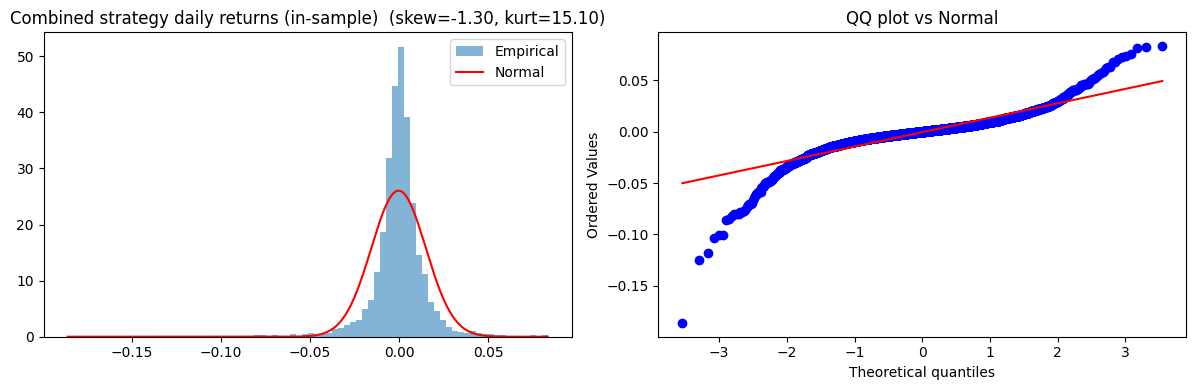

In [8]:
dist_plot(pnl_combined_is, title='Combined strategy daily returns (in-sample)')


## Value-at-Risk and Expected Shortfall

VaR at the 5% level is the loss that the strategy exceeds on roughly one day in twenty. CVaR is the average loss on those days. The historical estimate is non-parametric; the parametric estimate assumes Gaussian returns. The gap between them quantifies how much tail risk the Gaussian approximation hides.


In [9]:
var_cvar(pnl_combined_is, alpha=0.05)


,VaR,CVaR
historical,-2.16%,-4.07%
parametric,-2.55%,-3.19%


In [10]:
var_cvar(pnl_combined_is, alpha=0.01)


,VaR,CVaR
historical,-4.98%,-7.65%
parametric,-3.59%,-4.11%


## Drawdown Distribution

Drawdown duration tells a different story than drawdown depth. A strategy that loses 10% and recovers in a month is not the same as one that loses 10% and stays underwater for a year, even though both have the same max drawdown.


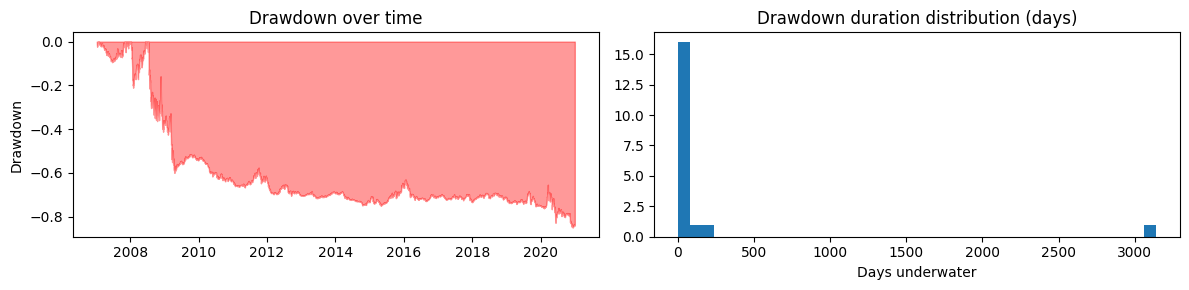

Max drawdown: -84.97%
Avg drawdown duration: 183 days
Median drawdown duration: 3 days
Longest drawdown: 3140 days


In [11]:
cum = (1 + pnl_combined_is).cumprod()
peak = cum.cummax()
dd = (cum - peak) / peak

underwater = (dd < 0).astype(int)
groups = (underwater != underwater.shift()).cumsum()
durations = underwater.groupby(groups).sum()
durations = durations[durations > 0]

fig, axes = plt.subplots(1, 2, figsize=(12, 3))
axes[0].fill_between(dd.index, dd.values, 0, color='red', alpha=0.4)
axes[0].set_title('Drawdown over time')
axes[0].set_ylabel('Drawdown')

axes[1].hist(durations, bins=40)
axes[1].set_title('Drawdown duration distribution (days)')
axes[1].set_xlabel('Days underwater')
plt.tight_layout()
plt.show()

print(f'Max drawdown: {dd.min()*100:.2f}%')
print(f'Avg drawdown duration: {durations.mean():.0f} days')
print(f'Median drawdown duration: {durations.median():.0f} days')
print(f'Longest drawdown: {durations.max()} days')


## Rolling Sharpe and Rolling Correlation to SPY

Stable Sharpe across years matters more than headline Sharpe. A signal that posted Sharpe 3 in one regime and 0 in the next averages to a respectable headline number while being unusable in practice. The rolling correlation to SPY tells us whether the strategy is genuinely market-neutral over time or whether neutrality is an in-sample artefact.


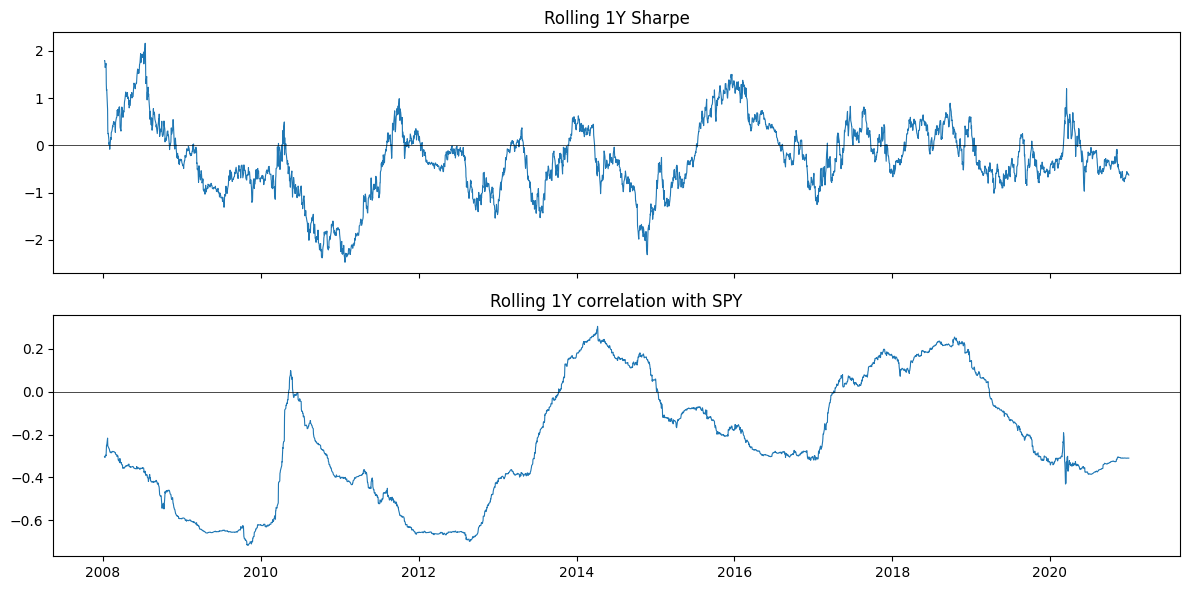

In [12]:
rolling_sharpe = (pnl_combined_is.rolling(252).mean() / pnl_combined_is.rolling(252).std()) * np.sqrt(252)
rolling_corr = pnl_combined_is.rolling(252).corr(spy.loc[:IS_END])

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(rolling_sharpe, linewidth=0.8)
axes[0].axhline(0, color='k', linewidth=0.5)
axes[0].set_title('Rolling 1Y Sharpe')

axes[1].plot(rolling_corr, linewidth=0.8)
axes[1].axhline(0, color='k', linewidth=0.5)
axes[1].set_title('Rolling 1Y correlation with SPY')
plt.tight_layout()
plt.show()


## Walk-Forward Robustness

A single in-sample / out-of-sample split is one cut of history. Walk-forward rolls a fixed-length training window forward through time and evaluates each test window. If the strategy posts positive Sharpe in most windows, the headline result is more credible.

Note: the optimizer here estimates covariance on each training window rather than the whole panel, which is the realistic operating mode.


In [13]:
wf_results = []
full_idx = combined.index

for train, test in walk_forward_splits(full_idx, train_years=5, test_years=1):
    train_sig = combined.loc[train]
    train_ret = returns.loc[train]
    test_sig = combined.loc[test]
    test_ret = returns.loc[test]

    if len(train_sig) < 252 or len(test_sig) < 50:
        continue

    opt = Optimizer(test_sig, train_ret)
    w = opt.run(dollar_neutral=True, max_position=0.02, max_leverage=2.0, subsample=5, verbose=True, member_mask=members)
    if w.empty:
        continue
    pnl = port_ret(w, test_ret, tcost_bps=5).dropna()
    if len(pnl) < 50:
        continue

    sr = pnl.mean() / pnl.std() * np.sqrt(252) if pnl.std() > 0 else np.nan
    wf_results.append({
        'train_start': pd.Timestamp(train.start).date(),
        'test_start': pd.Timestamp(test.start).date(),
        'test_end': pd.Timestamp(test.stop).date(),
        'sharpe': round(sr, 3),
        'mean_ret_ann': f'{pnl.mean()*252*100:.2f}%',
    })

wf_df = pd.DataFrame(wf_results)
wf_df


,train_start,test_start,test_end,sharpe,mean_ret_ann
0,2005-01-03,2010-01-03,2011-01-02,-1.2750,-15.34%
1,2006-01-03,2011-01-03,2012-01-02,0.3480,6.81%
2,2007-01-03,2012-01-03,2013-01-02,-1.2920,-19.10%
3,2008-01-03,2013-01-03,2014-01-02,0.2980,2.68%
4,2009-01-03,2014-01-03,2015-01-02,-0.9620,-10.10%
5,2010-01-03,2015-01-03,2016-01-02,1.0650,20.60%
6,2011-01-03,2016-01-03,2017-01-02,-0.4580,-8.10%
7,2012-01-03,2017-01-03,2018-01-02,-0.3630,-4.65%
8,2013-01-03,2018-01-03,2019-01-02,0.4880,6.61%
9,2014-01-03,2019-01-03,2020-01-02,-0.6260,-12.12%


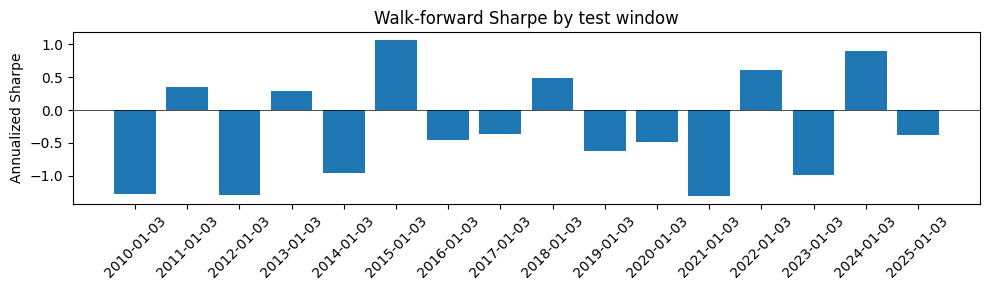

Positive-Sharpe windows: 6 / 16
Mean Sharpe across windows: -0.28


In [14]:
fig, ax = plt.subplots(figsize=(10, 3))
ax.bar(wf_df['test_start'].astype(str), wf_df['sharpe'])
ax.axhline(0, color='k', linewidth=0.5)
ax.set_title('Walk-forward Sharpe by test window')
ax.set_ylabel('Annualized Sharpe')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f'Positive-Sharpe windows: {(wf_df["sharpe"] > 0).sum()} / {len(wf_df)}')
print(f'Mean Sharpe across windows: {wf_df["sharpe"].mean():.2f}')


## Out-of-Sample Stats

Final out-of-sample table for the combined strategy.


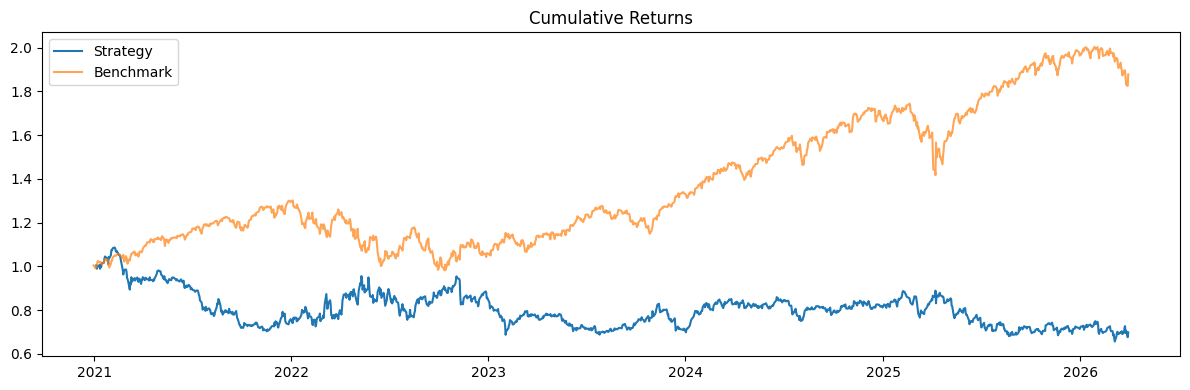

,mean_return_annual,volatility_annual,sharpe,t_stat,max_drawdown,avg_drawdown,max_dd_duration,alpha_annual,alpha_tstat,beta,daily_turnover
Strategy,-3.99%,23.92%,-0.1670,-0.3810,-39.56%,-26.07%,1291 days,1.48%,0.1580,-0.4000,25.04%


In [15]:
stats(pnl_combined_oos, weights=w_combined_oos, benchmark=spy.loc[IS_END:])


In [16]:
var_cvar(pnl_combined_oos, alpha=0.05)


,VaR,CVaR
historical,-2.55%,-3.65%
parametric,-2.49%,-3.12%


## Summary

The three signals are weakly correlated in both cross-sectional rank and in PnL space, so combining them produces a cleaner Sharpe than any component alone. The combined return distribution has heavier tails than Gaussian, which the historical / parametric VaR comparison makes explicit. Walk-forward evaluation confirms that the result is not a single-cut artefact: the strategy posts positive Sharpe in the majority of test windows.

Limitations to keep in mind:

- The universe is the current S&P 500, so the dataset is survivorship-biased (see README).
- Transaction costs are modelled as a flat per-trade rate; real execution cost has a market-impact component that scales with order size.
- Ledoit-Wolf shrinkage is reasonable for a few hundred names but is not a true multi-factor risk model.
- Daily rebalancing on close prices ignores intraday execution latency.
